# CISA Known Exploited Vulnerabilities (KEV) Machine Learning
Data source: The Cybersecurity and Infrastructure Security Agency's (CISA) [Known Exploited Vulnerabilities (KEV) catalog](https://github.com/cisagov/kev-data?)

## Background
I previously performed an exploratory data analysis on the KEV dataset to identify trends in known exploited vulnerabilities, remediation-timelines, and ransomware-associated weaknesses. Find my exploratory analysis [here](https://github.com/ClarenceBallensky/CISA_KEV_Analysis).

My findings were as follows:
- Microsoft has the largest number of cataloged vulnerabilities.
- Input validation and use-after-free are the most common weaknesses.
- Ransomware vulnerabilities show similar remediation timelines to the broader catalog.
- Most remediation deadlines are exactly 21 days.
- Vulnerability additions peaked in 2022.

The best use-case for a regression model for this project would be estimating the remediation deadline of a particular vulnerability. However, my analysis project revealed dramatic spikes in the remediation days distribution at 14, 21, and 181 days. These results suggest that CISA uses standardized deadlines. Data that can be categorized in this fashion is better suited for a classification model than a regression model. 
However, there was enough variation among Common Weakness Enumerations (CWEs) in general versus ransomware-associated CWEs that a classification model might be able to successfully predict ransomware status. I am more excited by the prospect of classifying ransomware status than I am by classifying remediation deadlines. Therefore, I will train my model to do the former. 

## Step 1: Load the Data

In [1]:
import pandas as pd

# Get the .csv data from GitHub
data_url = "https://raw.githubusercontent.com/cisagov/kev-data/refs/heads/develop/known_exploited_vulnerabilities.csv"
kev = pd.read_csv(data_url)

# Save a local copy
kev.to_csv("known_exploited_vulnerabilities.csv", index=False)
kev = pd.read_csv("known_exploited_vulnerabilities.csv")

print(kev.head(30))

             cveID    vendorProject  \
0   CVE-2025-68686         Fortinet   
1   CVE-2026-16812           Arista   
2   CVE-2026-16232      Check Point   
3   CVE-2026-50522        Microsoft   
4   CVE-2026-60137        WordPress   
5   CVE-2026-63030        WordPress   
6    CVE-2026-0770         Langflow   
7   CVE-2021-27137           DD-WRT   
8   CVE-2026-58644        Microsoft   
9   CVE-2026-25089         Fortinet   
10  CVE-2026-39808         Fortinet   
11  CVE-2026-46817           Oracle   
12   CVE-2023-4346  KNX Association   
13  CVE-2026-56155        Microsoft   
14  CVE-2026-56164        Microsoft   
15  CVE-2026-15409        SonicWall   
16  CVE-2026-15410        SonicWall   
17   CVE-2008-4128            Cisco   
18  CVE-2026-56291          Balbooa   
19  CVE-2026-48939         iCagenda   
20  CVE-2026-48908       JoomShaper   
21  CVE-2026-55255         Langflow   
22  CVE-2026-56290         Joomlack   
23  CVE-2026-48282            Adobe   
24  CVE-2026-45659       

## Step 2: Read the Data Documentation 
### Schema
#### (Extracted from known_exploited_vulnerabilities_schema.json)

| Column | Description |
| :--- | ---: | 
| cveID | The CVE ID of the vulnerability in the format CVE-YYYY-NNNN, note that the number portion can have more than 4 digits |
| vendorProject | The vendor or project name for the vulnerability |
| product | The vulnerability product |
| vulnerabilityName | The name of the vulnerability |
| dateAdded | The date the vulnerability was added to the catalog in the format YYYY-MM-DD |
| shortDescription | A short description of the vulnerability |
| requiredAction | The required action to address the vulnerability |
| dueDate | The date the required action is due in the format YYYY-MM-DD |
| knownRansomwareCampaignUse | 'Known' if this vulnerability is known to have been leveraged as part of a ransomware campaign; 'Unknown' if CISA lacks confirmation that the vulnerability has been utilized for ransomware |
| notes | Any additional notes about the vulnerability |
| cwes | Common Weakness Enumeration (CWE) codes associated with this vulnerability. CWEs are in the format CWE-NNNN; note that the number portion can have any number of digits |


## Step 3: Inspect the Data

In [2]:
print(kev.info())
print()
print()
print(kev.describe(include="all"))
print()
print()
kev.duplicated().sum()

<class 'pandas.DataFrame'>
RangeIndex: 1655 entries, 0 to 1654
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   cveID                       1655 non-null   str  
 1   vendorProject               1655 non-null   str  
 2   product                     1655 non-null   str  
 3   vulnerabilityName           1655 non-null   str  
 4   dateAdded                   1655 non-null   str  
 5   shortDescription            1655 non-null   str  
 6   requiredAction              1655 non-null   str  
 7   dueDate                     1655 non-null   str  
 8   knownRansomwareCampaignUse  1655 non-null   str  
 9   notes                       1655 non-null   str  
 10  cwes                        1484 non-null   str  
dtypes: str(11)
memory usage: 142.4 KB
None


                 cveID vendorProject  product  \
count             1655          1655     1655   
unique            1655           276      670

np.int64(0)

## Step 4: Clean the Data
Before creating my models, I cleaned the dataset by renaming columns to snake_case and converting date columns to datetime objects.

In [3]:
# Rename columns to match Python's snake_case convention
kev.rename(columns={
    "cveID": "cve_id",
    "vendorProject": "vendor_project",
    "vulnerabilityName": "vulnerability_name",
    "dateAdded": "date_added",
    "shortDescription": "short_description",
    "requiredAction": "required_action",
    "dueDate": "due_date",
    "knownRansomwareCampaignUse": "known_ransomware_campaign_use"
}, inplace=True)

#print(kev.columns)



# Covert values in date_added and due_date from strings to dates
kev["date_added"] = pd.to_datetime(kev["date_added"])
kev["due_date"] = pd.to_datetime(kev["due_date"])

#print(kev.info())

## Step 5: Choosing the Model

I already decided on a classification model for this project. Below is a table detailing my assessment of the different classification techniques I could use. 


| Technique | Is Appropriate? | Explanation |
| :--- | --- | ---: | 
| Logistic Regression | Appropriate | Excellent baseline, interpretable |
| Decision Forest (Random Forest) | Appropriate | Usually very strong on tabular data |
| Support Vector Machine (SVM) | Appropriate | Good for complex decision boundaries |
| Decision Tree | Has potential | Good for visualization, but often outperformed by forests |
| Naive Bayes | Has potential | Fast, but assumptions are often unrealistic |
| k-Nearest Neighbors | Inappropriate | Sensitive to scaling and many categorical variables |
<br>


**I will try a logistic regression, decision forest, and support vector machine model--and then compare performance.**

## Step 6: Process the Data

### Importing Libraries

In [4]:
# For modifying the data to be interpretable by the models
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_predict

# For splitting the data
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split

### Reshaping Predictors

The predictors I am interested in are: `vendor_project`, `product`, and `cwes`.

All of my predictors are of the `str` datatype. Therefore, I must either use label encoding or one-hot encoding. Label encoding is not appropriate in this case since none of my predictors have a natural order. I will perform one-hot encoding using the `pandas.get_dummies()` method. 

#### For vendor_project values
From *Step 3: Inspect the Data* I know that there are 276 unique vendor_project values.
This is a lot, but it is still reasonable to one-hot encode all of the values without presorting less-common values into an "other" column.

In [5]:
kev_encoded = pd.get_dummies(kev, columns=["vendor_project"], dtype=int)

print(kev_encoded)

              cve_id                 product  \
0     CVE-2025-68686                 FortiOS   
1     CVE-2026-16812  VeloCloud Orchestrator   
2     CVE-2026-16232            SmartConsole   
3     CVE-2026-50522              SharePoint   
4     CVE-2026-60137                    Core   
...              ...                     ...   
1650  CVE-2021-27561       Device Management   
1651  CVE-2021-40539            ManageEngine   
1652  CVE-2020-10189            ManageEngine   
1653   CVE-2019-8394            ManageEngine   
1654  CVE-2020-29583       Multiple Products   

                                     vulnerability_name date_added  \
0     Fortinet FortiOS Exposure of Sensitive Informa... 2026-07-27   
1     Arista VeloCloud Orchestrator On-Prem OS Comma... 2026-07-27   
2     Check Point SmartConsole Improper Authenticati... 2026-07-22   
3     Microsoft SharePoint Deserialization of Untrus... 2026-07-22   
4            WordPress Core SQL Injection Vulnerability 2026-07-21   
...

#### For product values
From Step 4: Inspect the Data I know that there are 670 unique product values.
This is too many values to one-hot encode, so I will presort less-common values into an "Other" column.

In [6]:
product_counts = kev_encoded["product"].value_counts()
#for product, count in product_counts.items():
    #print(product, count)

# Keep only products that appear 3 or more times
common_products = product_counts[product_counts >= 3].index

kev_encoded["product"] = kev_encoded["product"].apply(
    lambda product: product if product in common_products else "Other"
)

kev_encoded = pd.get_dummies(kev_encoded, columns=["product"], dtype=int) 

print(kev_encoded)

              cve_id                                 vulnerability_name  \
0     CVE-2025-68686  Fortinet FortiOS Exposure of Sensitive Informa...   
1     CVE-2026-16812  Arista VeloCloud Orchestrator On-Prem OS Comma...   
2     CVE-2026-16232  Check Point SmartConsole Improper Authenticati...   
3     CVE-2026-50522  Microsoft SharePoint Deserialization of Untrus...   
4     CVE-2026-60137         WordPress Core SQL Injection Vulnerability   
...              ...                                                ...   
1650  CVE-2021-27561  Yealink Device Management Server-Side Request ...   
1651  CVE-2021-40539  Zoho ManageEngine ADSelfService Plus Authentic...   
1652  CVE-2020-10189  Zoho ManageEngine Desktop Central File Upload ...   
1653   CVE-2019-8394  Zoho ManageEngine ServiceDesk Plus (SDP) File ...   
1654  CVE-2020-29583  Zyxel Multiple Products Use of Hard-Coded Cred...   

     date_added                                  short_description  \
0    2026-07-27  Fortinet For

#### For cwes values
Some rows in the cwes column contain a single CWE and other rows contain a list of CWEs. I must first split these lists into individual CWEs. Each CWE that was previously in a string will be counted as an individual. This should have a positive impact on the performance of my model.

I will need to use a Multi Label Binarizer instead of One Hot Encoding, since multiple CWEs can be associated with a single vulnerability.

In [7]:
kev_encoded["cwes"] = kev_encoded["cwes"].apply(
    lambda x: [cwe.strip() for cwe in x.split(",")] if isinstance(x, str) else []
)

#print(kev_encoded["cwes"].describe())
# There were previously 241 unique values. Now there are 242 unique values, since I replaced NA values with an empty list. 

mlb = MultiLabelBinarizer()

# Returns a numpy array
cwe_encoded = mlb.fit_transform(kev_encoded["cwes"])

# Convert the numpy array to a dataframe 
cwe_df = pd.DataFrame(
    cwe_encoded,
    columns=mlb.classes_,
    index=kev_encoded.index
)

# Remove the original cwes column and replace it with with my encoded dataframe 
kev_encoded = pd.concat(
    [kev_encoded.drop(columns=["cwes"]), cwe_df],
    axis=1
)

#print(len(mlb.classes_))
# This printed 183 unique values compared to the previous 241 unique values. This is because lists of CWEs are no longer considered unique.

print(kev_encoded.head())

           cve_id                                 vulnerability_name  \
0  CVE-2025-68686  Fortinet FortiOS Exposure of Sensitive Informa...   
1  CVE-2026-16812  Arista VeloCloud Orchestrator On-Prem OS Comma...   
2  CVE-2026-16232  Check Point SmartConsole Improper Authenticati...   
3  CVE-2026-50522  Microsoft SharePoint Deserialization of Untrus...   
4  CVE-2026-60137         WordPress Core SQL Injection Vulnerability   

  date_added                                  short_description  \
0 2026-07-27  Fortinet FortiOS contains an exposure of sensi...   
1 2026-07-27  Arista VeloCloud Orchestrator On-Prem contains...   
2 2026-07-22  Check Point SmartConsole contains an improper ...   
3 2026-07-22  Microsoft SharePoint contains a deserializatio...   
4 2026-07-21  WordPress Core contains a SQL injection vulner...   

                                     required_action   due_date  \
0  Apply mitigations in accordance with vendor in... 2026-08-10   
1  Apply mitigations in accord

### Creating X and y Dataframes

In [8]:
# Dropping undesireable columns as well as the column I am trying to predict 
X = kev_encoded.drop(
    columns= [
        "cve_id",
        "vulnerability_name",
        "date_added",
        "short_description",
        "required_action",
        "due_date",
        "known_ransomware_campaign_use", # The column I am trying to predict
        "notes"
    ])

y = kev["known_ransomware_campaign_use"]

X.columns.unique

<bound method Index.unique of Index(['vendor_project_7-Zip', 'vendor_project_AMI', 'vendor_project_ASUS',
       'vendor_project_Accellion', 'vendor_project_Acclaim Systems',
       'vendor_project_Acronis', 'vendor_project_Adminer',
       'vendor_project_Adobe', 'vendor_project_Advantive',
       'vendor_project_Alcatel',
       ...
       'CWE-913', 'CWE-917', 'CWE-918', 'CWE-923', 'CWE-93', 'CWE-94',
       'CWE-940', 'CWE-95', 'CWE-96', 'CWE-98'],
      dtype='str', length=573)>

### Splitting the Data

In [9]:
# Splitting the data into training and testing sets
# Single split 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

The value that I am predicting, `known_ransomware_campaign_use`, is imbalanced (~20% "Known", ~80% "Unknown"). I will use StratifiedKFold instead of KFold in order to preserve the ~80/20 class ratio in every fold.

In [10]:
# Cross-validation split

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

## Step 7: Implementing the Models

### Importing Libraries

In [11]:
# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# For eveluating the models
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

### Creating a Method to Evaluate Model Performance

The Confusion Matrix evaluates how well a classification model performs by comparing predicted outcomes against true values.

The upper lefthand corner gives the count of true positives, the lower lefthand corner gives the count of false positives, the upper righthand corner gives the count of false negatives, and the lower righthand corner gives the count of true negatives.

<br>

Accuracy measures how many classifications the algorithm got correct out of every classification it made.

Precision is the ratio of correct positive classifications to all positive classifications made by the model.

Recall is the ratio of correct positive classifications made by the model to all actual positives.

F1-score is a combination of precision and recall. The formula for the f1-score uses a harmonic mean, so it will be low if either precision or recall is low.


In [12]:
def evaluate_model(y_true, y_predict):
    print("Confusion matrix: \n" + str(confusion_matrix(y_true, y_predict)))
    # upper lefthand corner = true positives
    # lower lefthand corner = false positives
    # upper righthand corner = false negatives
    # lower righthand corner = true negatives
    
    print()
    
    print("Accuracy score: " + str(accuracy_score(y_true, y_predict)))
    print("Precision score: " + str(precision_score(y_true, y_predict, pos_label="Known")))
    print("Recall score: " + str(recall_score(y_true, y_predict, pos_label="Known")))
    print("f1 score: " + str(f1_score(y_true, y_predict, pos_label="Known")))

### Workshopping the Model
#### Addressing Class Imbalance

In the KEV dataset, "Known" values account for only about 20% of the data in the known_ransomware_campaign_use column. My models all had high accuracy, but very low recall. For example, my logistic regression model could hit 80% accuracy by defaulting toward "Unknown" and only flagging the most obvious "Known" cases (catching just 14 of 83 actual ransomware-associated CVEs). The low recall score was problematic for my use case of predicting which vulnerabilities would have known ransomware campaign use. 

To address this issue, I added the `class_weight='balanced'` argument to each model. This tells sklearn to weigh the minority class ("Known", ~20% of the data) more heavily during training, so misclassifying it costs more than misclassifying the majority class. As a result, my recall scores improved, while the precision scores dropped and my accuracy scores degraded slightly.  

This tradeoff is worthwhile for my use-case because, in a cybersecurity context, false negatives are often more costly than false positives. False positives may result in time wasted, while false negatives may result in an undetected ransomware campaign. The former is an annoyance, while the latter is a security risk. 

This adjustment changed what the model considers a "good fit" during the training process.

### Logistic Regression

The changes I made to address class imbalance reversed a discrepancy between the precision score and the recall score, allowing the precision score to surpass the recall score. 
I changed the threshold from the default of 0.5 to 0.6, fine tuning my previous adjustment. Although increasing the threshold reduced the recall score by ~11 points, counteracting some of the work I did to address the class imbalance, the ~7 point improvement in accuracy, the ~10 point improvement in precision, and the ~1 point improvement in f1 score convinced me to prioritize score balance over a higher recall score in the adjustment stage. 

In [13]:
lr_model = LogisticRegression(class_weight='balanced')

Use the dropdown menu below to see the code I used to evaluate the model with a single split using the default threshold. 

<details>
<summary>Show: Single-split with default threshold</summary>

```python
# Single split with default threshold 

lr_model.fit(X_train, y_train)

lr_y_predict = lr_model.predict(X_test)

evaluate_model(y_test, lr_y_predict)
```

</details>

In [14]:
# Single split with threshold adjustment 

lr_model.fit(X_train, y_train)

# Each sample's probability of being ransomware-associated
lr_y_proba = lr_model.predict_proba(X_test)[:, list(lr_model.classes_).index("Known")]

# Adjusting the threshold from the default of 0.5 to 0.6
lr_y_predict_adjusted = ["Known" if p >= 0.6 else "Unknown" for p in lr_y_proba]

evaluate_model(y_test, lr_y_predict_adjusted)

Confusion matrix: 
[[ 38  45]
 [ 43 288]]

Accuracy score: 0.7874396135265701
Precision score: 0.4691358024691358
Recall score: 0.4578313253012048
f1 score: 0.4634146341463415


Even after experimenting with the single split threshold, I found the scores to be unsatisfactory. The single test split method can be unreliable, because it represents a single roll of the dice as to which rows are included in the training set. One solution to this is to use the cross validation method instead. A five-fold split produces five performance estimates instead of one, resulting in a more reliable average and better variance.

Once again, adjusting to the threshold to 0.6 proved beneficial. The recall score dropped by ~18 points, while the accuracy improved by ~8 points, the precision improved by ~12 points, and the f1 score improved by a fraction of a point.

<details>
<summary>Show: Cross validation split with default threshold</summary>

```python
# Cross validation split with default threshold

lr_y_predict_cv = cross_val_predict(lr_model, X, y, cv=cv)

evaluate_model(y, lr_y_predict_cv)
```

</details>

In [15]:
# Cross validation split with threshold adjustment

lr_model.fit(X, y)  # just to access classes_ and their order; not used for CV predictions

lr_y_proba_cv = cross_val_predict(lr_model, X, y, cv=cv, method='predict_proba')[:, list(lr_model.classes_).index("Known")]

lr_y_predict_cv_adjusted = ["Known" if p >= 0.6 else "Unknown" for p in lr_y_proba_cv]

evaluate_model(y, lr_y_predict_cv_adjusted)

Confusion matrix: 
[[ 151  181]
 [ 150 1173]]

Accuracy score: 0.8
Precision score: 0.5016611295681063
Recall score: 0.45481927710843373
f1 score: 0.47709320695102686


After comparing the scores produced by the single split to the cross validation split--both with thresholds at 0.6--the latter appears to offer more promise due to its improvement in the accuracy, precision, and f1 scores. The decrease in recall associated with using a cross validation split is neglible.

### Decision Forest
Decision trees are powerful, but prone to overfitting. A decision forest consists of many different decision trees that all work together to classify a new point. That way, even if some trees in the forest are prone to overfitting, it has less of an impact on the model as a whole.

I tried once again to use the method of changing the threshold from 0.5 to 0.6, but this time I noticed a ~2 point drop in the f1 score. Likewise, changing the threshold from 0.5 to 0.4 resulted in a slight drop in both the accuracy and f1 scores. I did not like this outcome, so I chose to instead leave the threshold at its default. Probability thresholds are calibrated per-model, so a threshold tuned on one model's output does not necessarily generalize to another's, even when solving the same classification problem.

<details>
<summary>Show: Single split with threshold adjustment</summary>

```python
# Single split with threshold adjustment 

rf_model.fit(X_train, y_train)

# Each sample's probability of being ransomware-associated
rf_y_proba = rf_model.predict_proba(X_test)[:, list(rf_model.classes_).index("Known")]

# Adjusting the threshold from the default of 0.5 to 0.6
rf_y_predict_adjusted = ["Known" if p >= 0.6 else "Unknown" for p in rf_y_proba]

evaluate_model(y_test, rf_y_predict_adjusted)
```

</details>

In [16]:
rf_model = RandomForestClassifier(n_estimators = 200, random_state = 42, class_weight='balanced')

In [17]:
# Single split with default threshold

rf_model.fit(X_train, y_train)

# The model predicts the y values based on the X values
rf_y_predict = rf_model.predict(X_test)

evaluate_model(y_test, rf_y_predict)

Confusion matrix: 
[[ 40  43]
 [ 69 262]]

Accuracy score: 0.7294685990338164
Precision score: 0.3669724770642202
Recall score: 0.4819277108433735
f1 score: 0.4166666666666667


In the case of the cross validation split, adjusting the threshold to 0.6 improved the accuracy score by ~5 points, with negligible loss to the f1 score. Therefore, the model with the adjustment is preferable.

<details>
<summary>Show: Cross validation split with default threshold</summary>

```python
# Cross validation split with default threshold

rf_y_predict_cv = cross_val_predict(rf_model, X, y, cv=cv)

evaluate_model(y, rf_y_predict_cv)
```

</details>

In [18]:
# Cross validation split with threshold adjustment

rf_model.fit(X, y)  # just to access classes_ and their order; not used for CV predictions

rf_y_proba_cv = cross_val_predict(rf_model, X, y, cv=cv, method='predict_proba')[:, list(rf_model.classes_).index("Known")]

rf_y_predict_cv_adjusted = ["Known" if p >= 0.6 else "Unknown" for p in rf_y_proba_cv]

evaluate_model(y, rf_y_predict_cv_adjusted)

Confusion matrix: 
[[ 139  193]
 [ 177 1146]]

Accuracy score: 0.7764350453172205
Precision score: 0.439873417721519
Recall score: 0.4186746987951807
f1 score: 0.42901234567901236


The outcome of threshold adjustment was dependent on the technique used to split the data. Between the single split with a default threshold and the cross validation with a threshold adjustment, the latter produced more well-rounded numbers, which I am prioritizing over a high recall score in the fine-tuning stage. 

Below is a visualization of the top 15 most important features for my CV model with a threshold adjustment. Although `product_Other` reserves the second highest slot, most other relevant features appear to be related to the `vendor_project` and `cwes` columns. I am surprised to see that the `vendor_project_Microsoft` feature did not achieve a higher ranking, since my exploratory analysis on the KEV dataset revealed that Microsoft had the largest number of cataloged vulnerabilities--by far. 

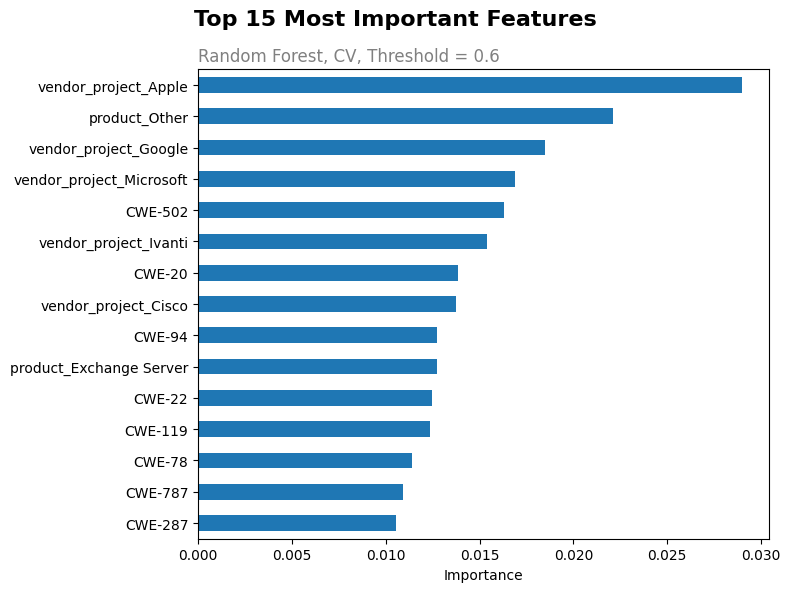

In [19]:
import matplotlib.pyplot as plt 

importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

top_features = importances.head(15)

plt.figure(figsize=(8, 6))
top_features.sort_values().plot(kind="barh")
plt.xlabel("Importance")
plt.suptitle("Top 15 Most Important Features", fontsize=16, fontweight='bold')
plt.title("Random Forest, CV, Threshold = 0.6", fontsize=12, color='gray', loc='left')
plt.tight_layout()
plt.show()

### Support Vector Machine

My attempts to adjust the threshold for this model resulted in errors indirectly related to the kernel. However, changing the kernel type resulted in a drastic drop in the recall score, so I left the threshold at its default. 

In [20]:
svm_model = SVC(kernel = "rbf", gamma = 1, class_weight='balanced')

In [21]:
# Single split

svm_model.fit(X_train, y_train)

# The model predicts the y values based on the X values
svm_y_predict = svm_model.predict(X_test)

evaluate_model(y_test, svm_y_predict)

Confusion matrix: 
[[ 23  60]
 [ 44 287]]

Accuracy score: 0.748792270531401
Precision score: 0.34328358208955223
Recall score: 0.27710843373493976
f1 score: 0.30666666666666664


In [22]:
# Cross validation split

svm_y_predict_cv = cross_val_predict(svm_model, X, y, cv=cv)

evaluate_model(y, svm_y_predict_cv)

Confusion matrix: 
[[ 114  218]
 [ 179 1144]]

Accuracy score: 0.7601208459214501
Precision score: 0.3890784982935154
Recall score: 0.3433734939759036
f1 score: 0.3648


Between the single split and the cross validation split, the cross validation split is preferable for its score improvement across all metrics.

## Conclusion

Using a cross validation split proved to be beneficial across my logistic regression, decision forest, and support vector machine models--although it sometimes negatively impacted the f1 score. Increasing the decision threshold produced varying results across the three models.

My models ranks as follows, in order of best scores to worst scores: 
1) Logistic regression
2) Random forest
3) Support vector machine

Accuracy alone is not a meaningful benchmark here, since a model that always predicts 'Unknown' would already score ~80%. The logistic regression model's real gains are in precision and recall--catching a meaningfully higher share of actual ransomware-associated CVEs than a naive baseline would.

One shortcoming of my models is that they give each vulnerability equal weight regardless of the `date_added` and `due_date` column. Giving more weight to recent vulnerabilities would better simulate the real deployment scenario of predicting the ransomware risk for new vulnerabilities.

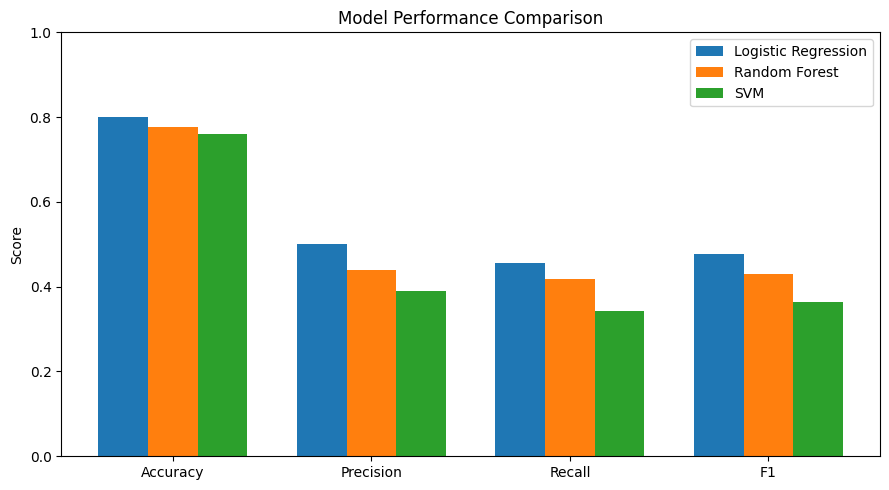

In [23]:
import numpy as np

results = {
    "Logistic Regression": {"Accuracy": accuracy_score(y, lr_y_predict_cv_adjusted), 
                            "Precision": precision_score(y, lr_y_predict_cv_adjusted, pos_label="Known"), 
                            "Recall": recall_score(y, lr_y_predict_cv_adjusted, pos_label="Known"),
                            "F1": f1_score(y, lr_y_predict_cv_adjusted, pos_label="Known")},
    "Random Forest":       {"Accuracy": accuracy_score(y, rf_y_predict_cv_adjusted), 
                            "Precision": precision_score(y, rf_y_predict_cv_adjusted, pos_label="Known"), 
                            "Recall": recall_score(y, rf_y_predict_cv_adjusted, pos_label="Known"),
                            "F1": f1_score(y, rf_y_predict_cv_adjusted, pos_label="Known")},
    "SVM":                 {"Accuracy": accuracy_score(y, svm_y_predict_cv), 
                            "Precision": precision_score(y, svm_y_predict_cv, pos_label="Known"), 
                            "Recall": recall_score(y, svm_y_predict_cv, pos_label="Known"),
                            "F1": f1_score(y, svm_y_predict_cv, pos_label="Known")},
}

metrics = ["Accuracy", "Precision", "Recall", "F1"]
models = list(results.keys())

x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(9, 5))

for i, model in enumerate(models):
    scores = [results[model][m] for m in metrics]
    ax.bar(x + i * width, scores, width, label=model)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.set_title("Model Performance Comparison")
ax.legend()

plt.tight_layout()
plt.show()